In [1]:
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib", "seaborn", "plotly"])

CompletedProcess(args=['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
df = pd.read_csv("Unemployment in India.csv")

# Strip spaces from column names
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (768, 7)

Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [4]:
df.head(25)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,31-10-2019,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,30-11-2019,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,31-12-2019,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,31-01-2020,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,29-02-2020,Monthly,5.91,11723617.0,42.83,Rural


In [5]:
print("\nRandom 10 Samples are:")
df.sample(10)


Random 10 Samples are:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
545,Karnataka,31-05-2020,Monthly,15.88,8669258.0,43.90,Urban
204,Meghalaya,30-06-2019,Monthly,4.23,1024797.0,61.09,Rural
253,Punjab,31-03-2020,Monthly,10.51,6373692.0,46.85,Rural
185,Madhya Pradesh,31-03-2020,Monthly,1.19,16480441.0,38.90,Rural
398,Assam,30-04-2020,Monthly,8.37,1454956.0,38.45,Urban
105,Haryana,30-04-2020,Monthly,41.61,4041050.0,49.85,Rural
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
633,Punjab,31-08-2019,Monthly,11.99,3499863.0,41.61,Urban
358,West Bengal,30-06-2020,Monthly,4.94,21225887.0,40.44,Rural
693,Telangana,29-02-2020,Monthly,6.74,5521496.0,45.78,Urban


In [6]:
print("=== Dataset Summary ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Area Types ===")
print(df['Area'].value_counts())

print("\n=== Unique Regions ===")
print(df['Region'].nunique(), "states/regions found")

=== Dataset Summary ===
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std                          10.721298        8.087988e+06   
min                           0.000000        4.942000e+04   
25%                           4.657500        1.190404e+06   
50%                           8.350000        4.744178e+06   
75%                          15.887500        1.127549e+07   
max                          76.740000        4.577751e+07   

       Estimated Labour Participation Rate (%)  
count                               740.000000  
mean                                 42.630122  
std                                   8.111094  
min                                  13.330000  
25%                                  38.062500  
50%                                  41.160000  
75%                                  45.505000  
max                      

In [7]:
# Convert Date to proper datetime format

df['Date'] = pd.to_datetime(df['Date'].str.strip(), dayfirst=True)

# Extract Month and Year for analysis
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print("Date range:", df['Date'].min(), "to", df['Date'].max())
df.head()

Date range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5.0,2019.0
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6.0,2019.0
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7.0,2019.0
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8.0,2019.0
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9.0,2019.0


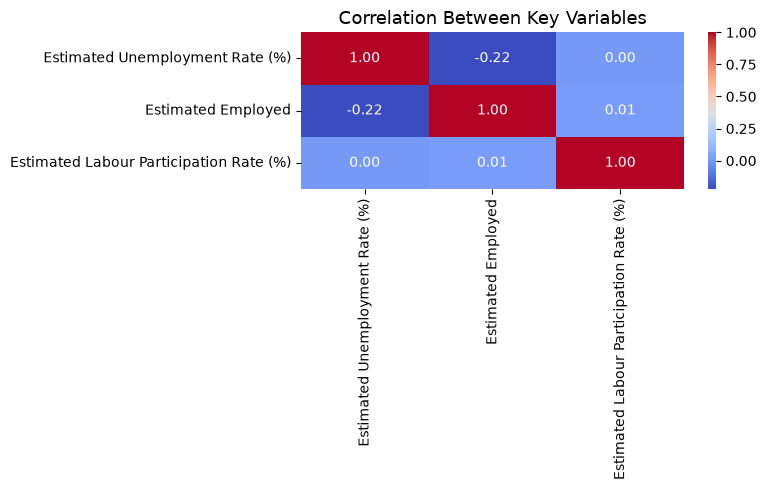

In [8]:
# CORRELATION HEATMAP

plt.figure(figsize=(8, 5))
sns.heatmap(df[['Estimated Unemployment Rate (%)',
                'Estimated Employed',
                'Estimated Labour Participation Rate (%)']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Key Variables', fontsize=13)
plt.tight_layout()
plt.show()

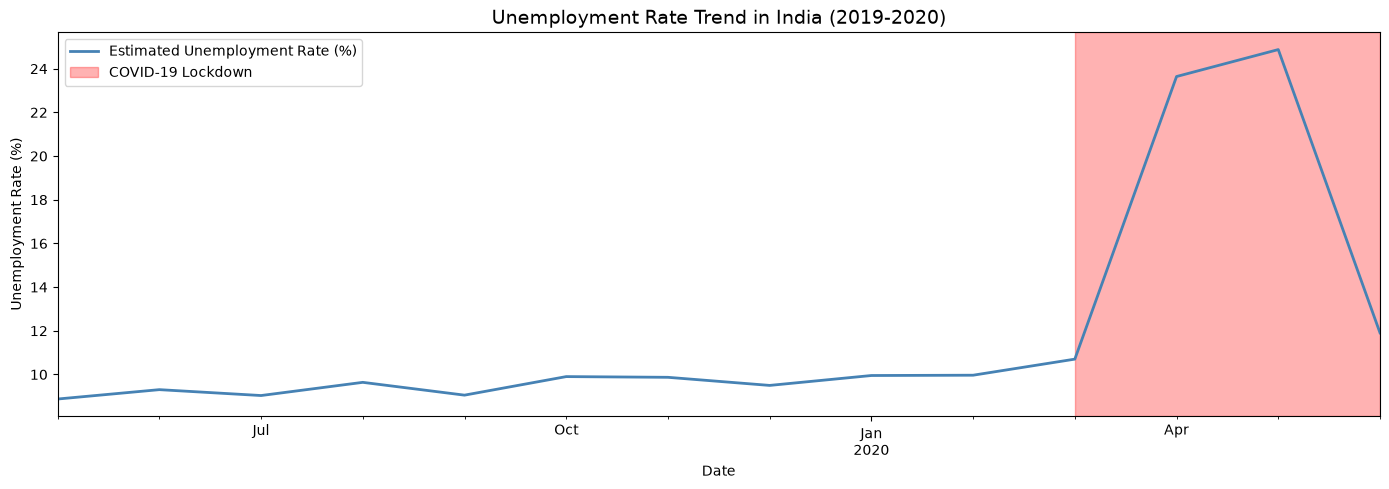

In [9]:
# OVERALL UNEMPLOYMENT TREND 

plt.figure(figsize=(14, 5))
df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().plot(
    color='steelblue', linewidth=2)

# Highlight COVID period
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
            alpha=0.3, color='red', label='COVID-19 Lockdown')

plt.title('Unemployment Rate Trend in India (2019-2020)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

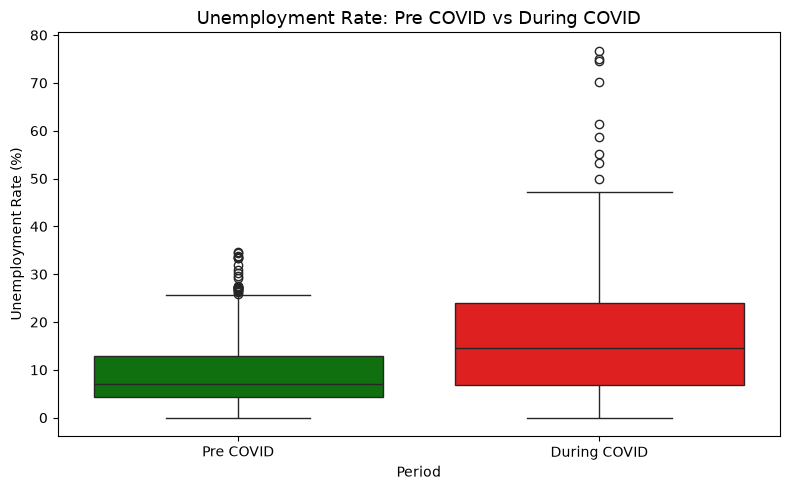

Average Unemployment Rate:
Period
During COVID    17.77
Pre COVID        9.51
Name: Estimated Unemployment Rate (%), dtype: float64


In [10]:
# Label Pre COVID and During COVID


df['Period'] = df['Date'].apply(
    lambda x: 'During COVID' if x >= pd.Timestamp('2020-03-01') else 'Pre COVID')

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Period', y='Estimated Unemployment Rate (%)',
            palette={'Pre COVID': 'green', 'During COVID': 'red'})
plt.title('Unemployment Rate: Pre COVID vs During COVID', fontsize=13)
plt.xlabel('Period')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

# Print average values
print("Average Unemployment Rate:")
print(df.groupby('Period')['Estimated Unemployment Rate (%)'].mean().round(2))

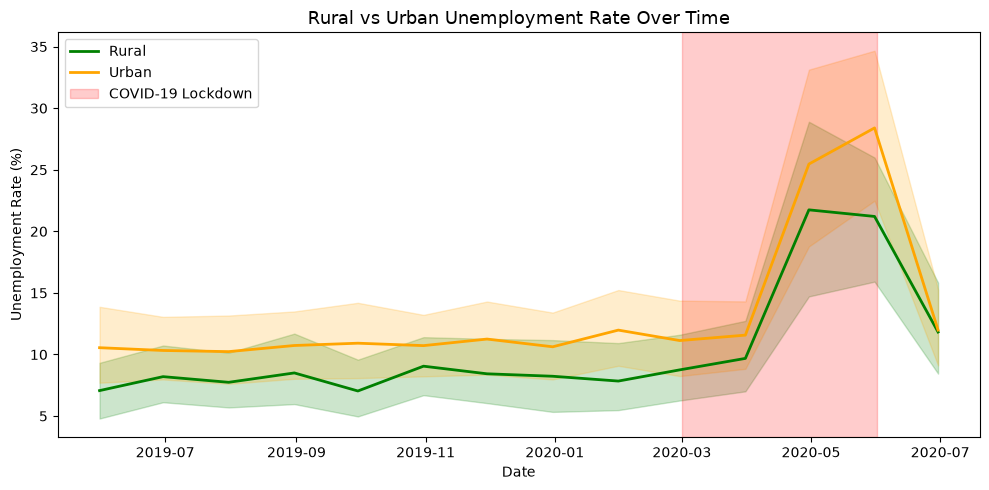

In [11]:
# RURAL AND URBAN COMPARISONS 

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)',
             hue='Area', palette={'Rural': 'green', 'Urban': 'orange'}, linewidth=2)

plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
            alpha=0.2, color='red', label='COVID-19 Lockdown')

plt.title('Rural vs Urban Unemployment Rate Over Time', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

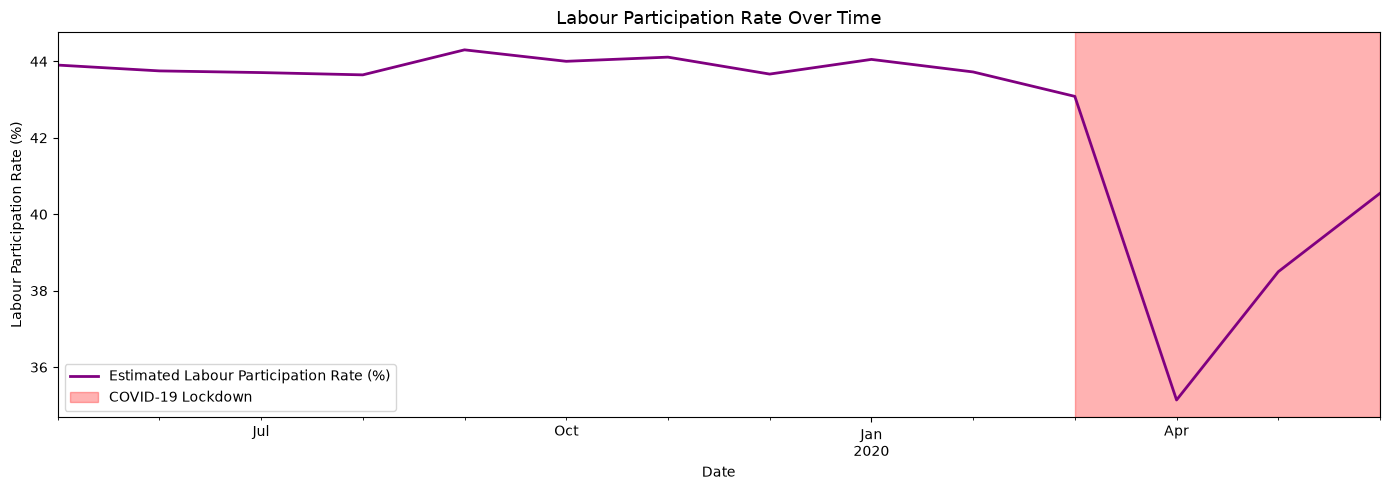

In [12]:
# LABOUR PARTICIPATION RATE ANALYSIS


plt.figure(figsize=(14, 5))
df.groupby('Date')['Estimated Labour Participation Rate (%)'].mean().plot(
    color='purple', linewidth=2)

plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
            alpha=0.3, color='red', label='COVID-19 Lockdown')

plt.title('Labour Participation Rate Over Time', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Labour Participation Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

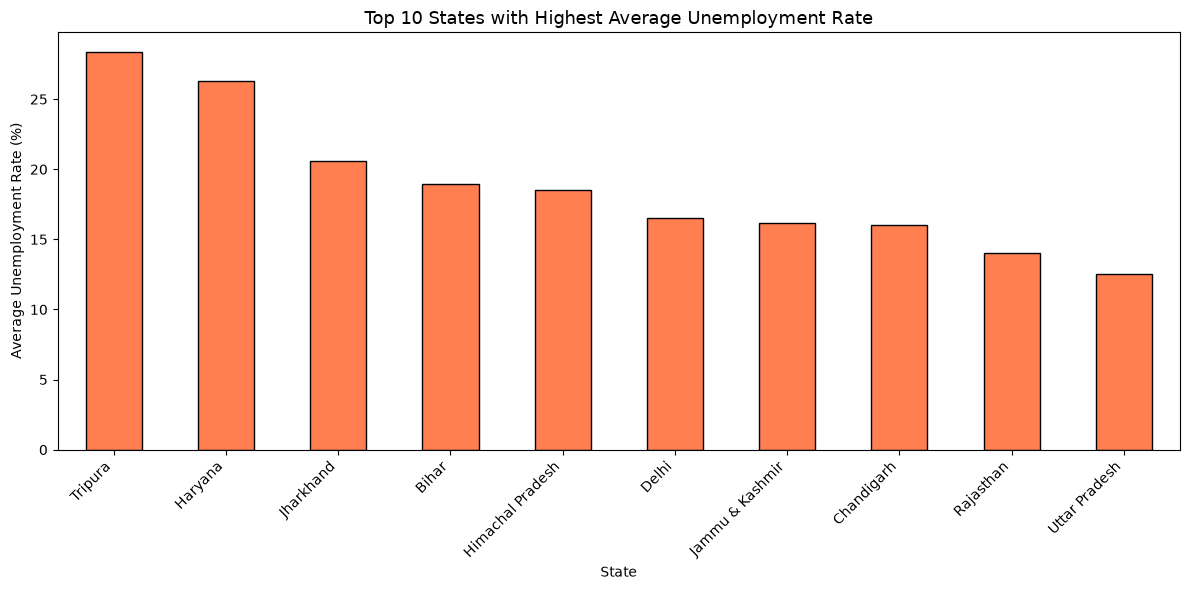


Top 3 Most Unemployed States:
Region
Tripura      28.350357
Haryana      26.283214
Jharkhand    20.585000
Name: Estimated Unemployment Rate (%), dtype: float64


In [13]:
# TOP 10 STATES BY UNEMPLOYMENT

state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
state_avg.head(10).plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 10 States with Highest Average Unemployment Rate', fontsize=13)
plt.xlabel('State')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 3 Most Unemployed States:")
print(state_avg.head(3))

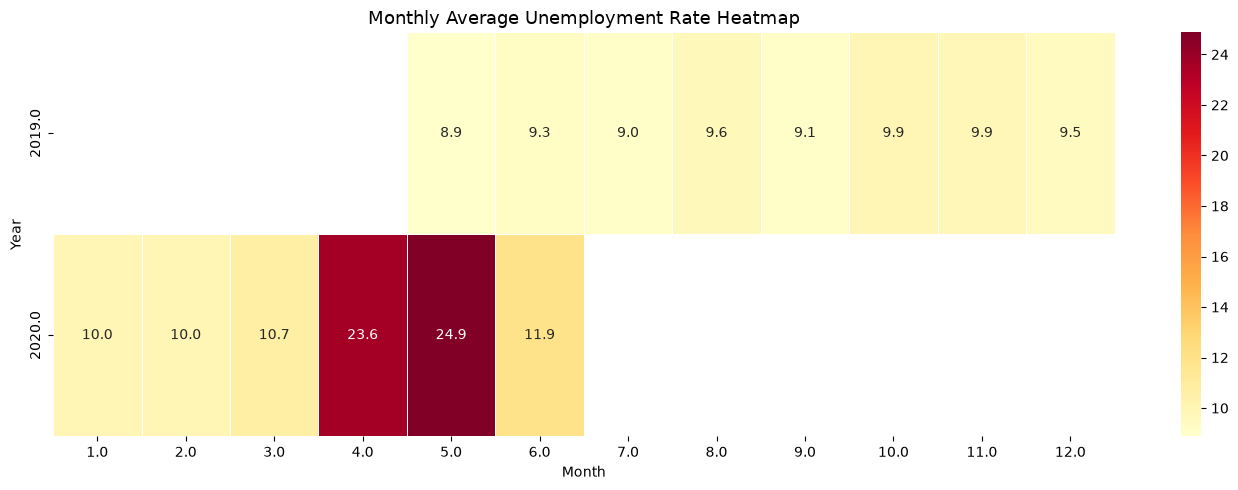

In [14]:
# MONTHLY UNEMPLOYMENT HEATMAP

pivot = df.groupby(['Year', 'Month'])['Estimated Unemployment Rate (%)'].mean().unstack()

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Monthly Average Unemployment Rate Heatmap', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

In [15]:
# KEY INSIGHTS SUMMARY


print("=" * 50)
print("        KEY INSIGHTS SUMMARY")
print("=" * 50)

print(f"\n📌 Total Records       : {df.shape[0]}")
print(f"📌 States Covered      : {df['Region'].nunique()}")
print(f"📌 Date Range          : {df['Date'].min().date()} to {df['Date'].max().date()}")

avg_pre = df[df['Period']=='Pre COVID']['Estimated Unemployment Rate (%)'].mean()
avg_covid = df[df['Period']=='During COVID']['Estimated Unemployment Rate (%)'].mean()

print(f"\n📌 Avg Unemployment Pre COVID    : {avg_pre:.2f}%")
print(f"📌 Avg Unemployment During COVID : {avg_covid:.2f}%")
print(f"📌 Increase due to COVID         : {avg_covid - avg_pre:.2f}%")
print(f"\n📌 Highest Unemployed State : {state_avg.index[0]}")
print(f"📌 Lowest Unemployed State  : {state_avg.index[-1]}")

avg_labour_pre = df[df['Period']=='Pre COVID']['Estimated Labour Participation Rate (%)'].mean()
avg_labour_covid = df[df['Period']=='During COVID']['Estimated Labour Participation Rate (%)'].mean()

print(f"\n📌 Avg Labour Participation Pre COVID    : {avg_labour_pre:.2f}%")
print(f"📌 Avg Labour Participation During COVID : {avg_labour_covid:.2f}%")
print(f"📌 Change in Labour Participation        : {avg_labour_covid - avg_labour_pre:.2f}%")
print("=" * 50)

        KEY INSIGHTS SUMMARY

📌 Total Records       : 768
📌 States Covered      : 28
📌 Date Range          : 2019-05-31 to 2020-06-30

📌 Avg Unemployment Pre COVID    : 9.51%
📌 Avg Unemployment During COVID : 17.77%
📌 Increase due to COVID         : 8.26%

📌 Highest Unemployed State : Tripura
📌 Lowest Unemployed State  : Meghalaya

📌 Avg Labour Participation Pre COVID    : 43.89%
📌 Avg Labour Participation During COVID : 39.33%
📌 Change in Labour Participation        : -4.56%
